In [ ]:
#2. Practical Case

In [3]:
print("📂 Leyendo el contrato desde el archivo local 'Contrato_ejercicio.pdf'...")

import fitz  # PyMuPDF

📂 Leyendo el contrato desde el archivo local 'Contrato_ejercicio.pdf'...


In [5]:
# Nombre del archivo (ya cargado en tu entorno local)
pdf_filename = "Contrato_ejercicio.pdf"

In [7]:
# Leer contenido del PDF
with fitz.open(pdf_filename) as doc:
    text = ""
    for page in doc:
        text += page.get_text()

print("\n📄 Texto extraído del contrato:")
print("="*80)
print(text[:1000])  # Muestra solo los primeros 1000 caracteres
print("="*80)

from transformers import pipeline


📄 Texto extraído del contrato:
ARRENDAMIENTO DE LOCAL COMERCIAL 
 
 
Conste por la suscripción del presente contrato de Arrendamiento o Alquiler del Local 
Comercial que celebran, de una parte ZAMORA QUISPE, MARÍA ELENA, 
identificada con DNI N.º 00000001, con domicilio real en Calle Los Cipreses N.º 123, 
Urb. Jardines del Sol, Distrito de San Martín de Porres, a quien en adelante se le 
denominará LA DUEÑA o ARRENDADORA; y de la otra parte, el señor 
VELÁSQUEZ MENDOZA, JULIO, identificado con DNI N.º 00000002, con domicilio 
en Mz. A Lt. 15, Conjunto Residencial Santa Clara, Distrito de Los Olivos, a quien 
en adelante se le denominará EL ARRENDATARIO o INQUILINO, bajo los 
siguientes términos: 
 
ANTECEDENTES 
 
 
PRIMERA: LA ARRENDADORA declara ser propietaria del inmueble ubicado en la 
Av. Los Laureles N.º 450, Mz. B Lt. 20, Urb. Villa Central, Distrito de 
Independencia, entre las avenidas Los Laureles y Alameda del Norte. 
 
 
SEGUNDA: LA ARRENDADORA deja constancia que el loc

In [9]:
# Cargar modelo
print("\n⏳ Cargando modelo 'facebook/bart-large-cnn' para generar resumen...")
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
print("✅ Modelo cargado.")


⏳ Cargando modelo 'facebook/bart-large-cnn' para generar resumen...


config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

C:\Users\ARIANA\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ARIANA\.cache\huggingface\hub\models--facebook--bart-large-cnn. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


✅ Modelo cargado.


In [11]:
# 👉 Fragmentar el texto en partes de máximo 1000 caracteres
def split_text(text, max_length=1000):
    return [text[i:i + max_length] for i in range(0, len(text), max_length)]

text_chunks = split_text(text)
print(f"\n📑 Fragmentos generados: {len(text_chunks)}\n")


📑 Fragmentos generados: 11



In [13]:
# 👉 Generar resumen por fragmento
summaries = []
for i, chunk in enumerate(text_chunks):
    print(f"🔄 Resumiendo fragmento {i + 1}/{len(text_chunks)}...")
    summary = summarizer(chunk, max_length=130, min_length=30, do_sample=False)
    summaries.append(summary[0]['summary_text'])

🔄 Resumiendo fragmento 1/11...
🔄 Resumiendo fragmento 2/11...
🔄 Resumiendo fragmento 3/11...
🔄 Resumiendo fragmento 4/11...
🔄 Resumiendo fragmento 5/11...
🔄 Resumiendo fragmento 6/11...
🔄 Resumiendo fragmento 7/11...
🔄 Resumiendo fragmento 8/11...
🔄 Resumiendo fragmento 9/11...
🔄 Resumiendo fragmento 10/11...
🔄 Resumiendo fragmento 11/11...


In [15]:

# 👉 Unir todos los resúmenes en uno final
final_summary = ' '.join(summaries)

In [17]:
# 👉 Mostrar el resumen final
print("\n📝 ✅ Resumen ejecutivo generado:")
print("="*80)
print(final_summary)
print("="*80)


📝 ✅ Resumen ejecutivo generado:
Arrendamiento o Alquiler del Local                 Comercial que celebran, de una parte ZAMORA QUISPE, MARÍA ELENA, y de la otra parte, el señor VELÁSQUEZ MENDOZA, JULIO. La Alameda del Norte N.º 451, en buen estado de conservación y habitabilidad, con piso de cerámica tipo porcelanato. El presente contrato, LA ARRENDADORA se obliga a ceder el uso del local comercial, concerniente como local comerscial, a favor of EL  ARRENDATARIO, a título de alquiler. El monto de la renta pactada en la cláusula siguiente. La renta será pago por mensualidades, realizándose el abono 11 de cada mes. El comprobante de pago deberá ser enviado por correo electrónico o entregado a LA ARRENDADORA dentro of las 24 horas posteriores a cada depósito. El Código Civil está obligado a pagar puntualmente el monto de todos los servicios inherentes al bien tales como agua y luz eléctrica, parques y jardines with el impuesto del Patrimonio. Así mismo, EL ARRENDATARIO esta obligado toda

In [19]:
# 👉 Guardar el resumen en un archivo .txt
with open("resumen_contrato.txt", "w", encoding="utf-8") as f:
    f.write(final_summary)

print("💾 El resumen ha sido guardado como 'resumen_contrato.txt'")

💾 El resumen ha sido guardado como 'resumen_contrato.txt'


In [ ]:
#1. Financial Phrasebank

In [23]:
pip install datasets


Note: you may need to restart the kernel to use updated packages.


In [25]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [27]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [29]:
from datasets import load_dataset

# ⚠️ Se requiere permitir código remoto para este dataset
dataset = load_dataset('financial_phrasebank', 'sentences_allagree', trust_remote_code=True)

# 👀 Mostrar el primer ejemplo
print("🔍 Primer ejemplo del dataset:")
print(dataset['train'][0])


🔍 Primer ejemplo del dataset:
{'sentence': 'According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .', 'label': 1}


In [31]:
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# 🔧 Cargar modelo y tokenizador FinBERT (tono financiero)
model_name = 'yiyanghkust/finbert-tone'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# ⚙️ Crear pipeline de análisis de sentimientos
classifier = pipeline('sentiment-analysis', model=model, tokenizer=tokenizer)


vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

C:\Users\ARIANA\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ARIANA\.cache\huggingface\hub\models--yiyanghkust--finbert-tone. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Device set to use cpu


In [33]:
# 👀 Mostrar los primeros 3 ejemplos para verificar la estructura
print("🧾 Ejemplos de frases del dataset:")
print(dataset['train'][:3])


🧾 Ejemplos de frases del dataset:
{'sentence': ['According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .', "For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .", 'In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn .'], 'label': [1, 2, 2]}


In [35]:
# 📊 Aplicar análisis de sentimiento a las primeras 10 frases
sentences_sample = dataset['train']['sentence'][:10]
predictions_sample = [classifier(sentence)[0]['label'] for sentence in sentences_sample]

# 🖨️ Mostrar resultados
print("📌 Resultados de clasificación (10 frases):")
for sentence, sentiment in zip(sentences_sample, predictions_sample):
    print(f"💬 Frase: {sentence} \n➡️ Sentimiento: {sentiment}\n")


📌 Resultados de clasificación (10 frases):
💬 Frase: According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing . 
➡️ Sentimiento: Neutral

💬 Frase: For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m . 
➡️ Sentimiento: Positive

💬 Frase: In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn . 
➡️ Sentimiento: Positive

💬 Frase: Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net sales . 
➡️ Sentimiento: Positive

💬 Frase: Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , representing 9.7 % of net sales . 
➡️ Sentimiento: Positive

💬 Frase: Finnish Talentum reports its operating profit increased to EUR 20.5 mn in 2005 from EUR 9.3 mn

In [37]:
import pandas as pd

# 🧠 Aplicar clasificación a todas las frases del dataset
all_sentences = dataset['train']['sentence']
all_predictions = [classifier(sentence)[0]['label'] for sentence in all_sentences]

# 📄 Crear DataFrame con resultados
results = pd.DataFrame({
    'sentence': all_sentences,
    'predicted_sentiment': all_predictions
})

# 💾 Guardar resultados en CSV
results.to_csv('sentiment_predictions_all.csv', index=False)
print("✅ Resultados guardados en 'sentiment_predictions_all.csv'")


✅ Resultados guardados en 'sentiment_predictions_all.csv'


In [39]:
pip install openpyxl


Note: you may need to restart the kernel to use updated packages.


In [41]:
# 🧾 Guardar también como archivo Excel
results.to_excel('sentiment_predictions_all.xlsx', index=False)
print("✅ Resultados también guardados en 'sentiment_predictions_all.xlsx'")


✅ Resultados también guardados en 'sentiment_predictions_all.xlsx'


C:\Users\ARIANA\AppData\Local\Temp\ipykernel_26116\1798125447.py:14: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ARIANA\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


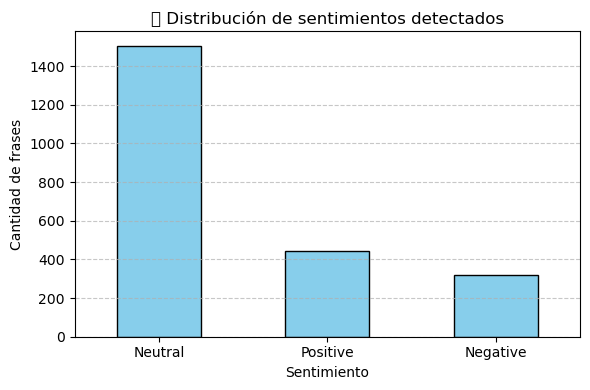

In [43]:
import matplotlib.pyplot as plt

# 📊 Contar frecuencia de cada sentimiento
sentiment_counts = results['predicted_sentiment'].value_counts()

# 🎨 Crear gráfico de barras
plt.figure(figsize=(6, 4))
sentiment_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('📈 Distribución de sentimientos detectados')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de frases')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
